# Demand Forecasting from CSV (LightGBM + Naive + W-37)

In [7]:
import os
from ibm_watsonx_ai import APIClient, Credentials
import getpass

credentials = Credentials(
    url="https://us-south.ml.cloud.ibm.com",
    api_key= "xxxxxx-xxxxxxxxxxxxxx" # use this API or create your API 
)


In [8]:
client = APIClient(credentials)
space_id = "xxxxx-xxxx-xxx-xxxx-xxxxxxxxxx"  # # get you space_id
client.set.default_space(space_id)
source_project_id = project.get_metadata()['metadata']['guid']

project_lib is deprecated and will no longer be available in IBM Runtime 25.1.
Please upgrade to ibm_watson_studio_lib instead.


In [9]:

# Install required packages (run once, then restart kernel)
%pip install "numpy<2" pandas matplotlib lightgbm scikit-learn pyarrow


Note: you may need to restart the kernel to use updated packages.


In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor, early_stopping


In [11]:

import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='N9FMTdZkNa9cGLqLoD_kpLDRh4A9bscRzoD2v-EPeRaZ',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'bootcampgov-donotdelete-pr-wzgtsjo1xuekfj'
object_key = 'training_data_221208.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)


,PART_NUM,PART_DTE,STOCKING_PCT,PART_SALES_QTY,PART_SALES_AMT,PART_SHIP_QTY,PART_SHIP_AMT,PART_DEMAND,PART_CLASS_CDE,target,...,PART_SALES_QTY_lag2,PART_SALES_QTY_lag3,PART_SALES_QTY_lag4,PART_SALES_QTY_lag5,PART_SALES_QTY_lag6,rmean_PART_SALES_QTY_3,month,quarter,year,age_month
0,0,2013-12-01,0.0,50.0,5508.0,50.0,5508.0,NaN,9,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,12.98
1,16,2013-12-01,0.0,17.0,3123.0,-35.0,-6437.0,NaN,9,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,20.04
2,17,2013-12-01,98.5,1046.0,2092.0,1045.0,2090.0,NaN,12,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,74.45
3,18,2013-12-01,95.6,92.0,3312.0,92.0,3312.0,NaN,1,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,87.07
4,19,2013-12-01,0.0,32.0,3947.0,32.0,3947.0,NaN,9,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,34.86
5,21,2013-12-01,88.5,434.0,43453.0,224.0,22427.0,NaN,1,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,57.13
6,26,2013-12-01,91.3,181.0,52581.0,175.0,50836.0,NaN,1,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,101.92
7,27,2013-12-01,91.7,142.0,35270.0,131.0,32589.0,NaN,12,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,25.20
8,40,2013-12-01,72.9,462.0,6468.0,424.0,5945.0,NaN,1,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,7.92
9,41,2013-12-01,70.8,49.0,686.0,46.0,644.0,NaN,12,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,12,4,2013,7.92


In [12]:
df_1 = df_1.iloc[50000:]


df_1["PART_DTE"] = pd.to_datetime(df_1["PART_DTE"], errors="coerce").dt.strftime("%Y-%m-%d")
cols_to_clean = df_1.columns.difference(["PART_DTE"])

df_1[cols_to_clean] = (
    df_1[cols_to_clean]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .astype(float)
)



In [13]:
df_1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66641 entries, 50000 to 116640
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PART_NUM                66641 non-null  float64
 1   PART_DTE                66641 non-null  object 
 2   STOCKING_PCT            66641 non-null  float64
 3   PART_SALES_QTY          66641 non-null  float64
 4   PART_SALES_AMT          66641 non-null  float64
 5   PART_SHIP_QTY           66641 non-null  float64
 6   PART_SHIP_AMT           66641 non-null  float64
 7   PART_DEMAND             66641 non-null  float64
 8   PART_CLASS_CDE          66641 non-null  float64
 9   target                  66641 non-null  float64
 10  PART_SALES_QTY_lag1     66641 non-null  float64
 11  PART_SALES_QTY_lag2     66641 non-null  float64
 12  PART_SALES_QTY_lag3     66641 non-null  float64
 13  PART_SALES_QTY_lag4     66641 non-null  float64
 14  PART_SALES_QTY_lag5     66641 non

In [14]:
df=df_1
df

,PART_NUM,PART_DTE,STOCKING_PCT,PART_SALES_QTY,PART_SALES_AMT,PART_SHIP_QTY,PART_SHIP_AMT,PART_DEMAND,PART_CLASS_CDE,target,...,PART_SALES_QTY_lag2,PART_SALES_QTY_lag3,PART_SALES_QTY_lag4,PART_SALES_QTY_lag5,PART_SALES_QTY_lag6,rmean_PART_SALES_QTY_3,month,quarter,year,age_month
50000,973.0,2017-12-01,79.0,140.0,16.0,140.0,15.0,127.0,5.0,330.0,...,232.0,212.0,306.0,240.0,230.0,227.666667,12.0,4.0,2017.0,490.98
50001,974.0,2017-12-01,69.0,282.0,113.0,282.0,97.0,282.0,5.0,460.0,...,250.0,230.0,240.0,250.0,271.0,304.000000,12.0,4.0,2017.0,490.98
50002,975.0,2017-12-01,70.0,156.0,27.0,156.0,27.0,151.0,5.0,115.0,...,195.0,118.0,110.0,134.0,95.0,155.333333,12.0,4.0,2017.0,490.98
50003,976.0,2017-12-01,69.4,262.0,304.0,255.0,295.0,114.0,5.0,223.0,...,259.0,277.0,341.0,270.0,350.0,252.666667,12.0,4.0,2017.0,490.98
50004,977.0,2017-12-01,77.1,457.0,503.0,457.0,503.0,457.0,5.0,484.0,...,698.0,583.0,920.0,753.0,1043.0,592.333333,12.0,4.0,2017.0,444.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116636,1141.0,2022-10-01,0.0,0.0,0.0,0.0,0.0,39.0,9.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,10.0,4.0,2022.0,109.77
116637,1142.0,2022-10-01,0.0,0.0,0.0,0.0,0.0,93.0,9.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,10.0,4.0,2022.0,109.77
116638,1143.0,2022-10-01,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,10.0,4.0,2022.0,109.77
116639,1144.0,2022-10-01,0.0,0.0,0.0,0.0,0.0,79.0,9.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,10.0,4.0,2022.0,109.77


In [15]:

# Load CSV (CHANGE PATH)
#df = pd.read_csv("your_file.csv")

df["PART_DTE"] = pd.to_datetime(df["PART_DTE"], errors="coerce")
df = df.dropna(subset=["PART_DTE"])
df = df.sort_values(["PART_NUM", "PART_DTE"]).reset_index(drop=True)

print(df.shape)
df.head()


(66641, 21)


,PART_NUM,PART_DTE,STOCKING_PCT,PART_SALES_QTY,PART_SALES_AMT,PART_SHIP_QTY,PART_SHIP_AMT,PART_DEMAND,PART_CLASS_CDE,target,...,PART_SALES_QTY_lag2,PART_SALES_QTY_lag3,PART_SALES_QTY_lag4,PART_SALES_QTY_lag5,PART_SALES_QTY_lag6,rmean_PART_SALES_QTY_3,month,quarter,year,age_month
0,0.0,2018-01-01,0.0,53.0,5157.0,51.0,4963.0,34.0,9.0,31.0,...,91.0,110.0,116.0,117.0,130.0,63.666667,1.0,1.0,2018.0,62.00
1,0.0,2018-02-01,0.0,63.0,6113.0,63.0,6113.0,31.0,9.0,100.0,...,47.0,91.0,110.0,116.0,117.0,54.333333,2.0,1.0,2018.0,63.02
2,0.0,2018-03-01,0.0,146.0,14178.0,145.0,14081.0,100.0,9.0,76.0,...,53.0,47.0,91.0,110.0,116.0,87.333333,3.0,1.0,2018.0,63.94
3,0.0,2018-04-01,0.0,195.0,18945.0,194.0,18848.0,76.0,9.0,84.0,...,63.0,53.0,47.0,91.0,110.0,134.666667,4.0,2.0,2018.0,64.95
4,0.0,2018-05-01,0.0,153.0,14852.0,150.0,14560.0,84.0,9.0,93.0,...,146.0,63.0,53.0,47.0,91.0,164.666667,5.0,2.0,2018.0,65.94


In [16]:

# Train / Validation split
X = df.drop(columns=["target", "PART_DTE"])
y = df["target"]

split_year = X["year"].quantile(0.8)
mask = X["year"] <= split_year

X_train, X_val = X[mask], X[~mask]
y_train, y_val = y[mask], y[~mask]


In [17]:
X_test = X.tail(1000)
y_test = y.tail(1000)


In [18]:
X_test


,PART_NUM,STOCKING_PCT,PART_SALES_QTY,PART_SALES_AMT,PART_SHIP_QTY,PART_SHIP_AMT,PART_DEMAND,PART_CLASS_CDE,PART_SALES_QTY_lag1,PART_SALES_QTY_lag2,PART_SALES_QTY_lag3,PART_SALES_QTY_lag4,PART_SALES_QTY_lag5,PART_SALES_QTY_lag6,rmean_PART_SALES_QTY_3,month,quarter,year,age_month
65641,1129.0,0.0,0.0,0.0,0.0,0.0,44.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,1.333333,3.0,1.0,2018.0,113.81
65642,1129.0,0.0,0.0,0.0,0.0,0.0,67.0,3.0,0.0,4.0,0.0,0.0,0.0,0.0,1.333333,4.0,2.0,2018.0,114.83
65643,1129.0,0.0,0.0,0.0,0.0,0.0,82.0,3.0,0.0,0.0,4.0,0.0,0.0,0.0,0.000000,5.0,2.0,2018.0,115.81
65644,1129.0,0.0,0.0,0.0,0.0,0.0,100.0,3.0,0.0,0.0,0.0,4.0,0.0,0.0,0.000000,6.0,2.0,2018.0,116.83
65645,1129.0,0.0,0.0,0.0,0.0,0.0,85.0,3.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,7.0,3.0,2018.0,117.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66636,1145.0,0.0,0.0,0.0,0.0,0.0,531.0,9.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,6.0,2.0,2022.0,105.76
66637,1145.0,0.0,0.0,0.0,0.0,0.0,636.0,9.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,7.0,3.0,2022.0,106.75
66638,1145.0,0.0,0.0,0.0,0.0,0.0,599.0,9.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,8.0,3.0,2022.0,107.76
66639,1145.0,0.0,0.0,0.0,0.0,0.0,549.0,9.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,9.0,3.0,2022.0,108.78


In [19]:
train_df = pd.concat([X_train, y_train.rename("target")], axis=1)
train_df.to_csv("training_data.csv", index=False)

test_df = pd.concat([X_test, y_test.rename("target")], axis=1)
test_df.to_csv("test_data.csv", index=False)


In [20]:
project.save_data(
    data=open("/home/wsuser/work/test_data.csv", "rb"),
    file_name="test_data.csv",
    overwrite=True
)

project_lib is deprecated and will no longer be available in IBM Runtime 25.1.
Please upgrade to ibm_watson_studio_lib instead.


{'file_name': 'test_data.csv',
 'message': 'File saved to project storage.',
 'bucket_name': 'hondabootcampaigov-donotdelete-pr-4y2nqxf2luknsv',
 'asset_id': '1ef9ab5f-97b5-4db7-88e5-8b55e7c6af00'}

In [21]:
project.save_data(
    data=open("/home/wsuser/work/training_data.csv", "rb"),
    file_name="training_data.csv",
    overwrite=True
)

project_lib is deprecated and will no longer be available in IBM Runtime 25.1.
Please upgrade to ibm_watson_studio_lib instead.


{'file_name': 'training_data.csv',
 'message': 'File saved to project storage.',
 'bucket_name': 'hondabootcampaigov-donotdelete-pr-4y2nqxf2luknsv',
 'asset_id': 'bdb841c6-5d69-4865-8e2e-6e35eb5f910f'}

In [22]:
from lightgbm import LGBMRegressor, early_stopping

# Train LightGBM (4.x compatible)
def train_lgbm_model(x_train, y_train, x_valid, y_valid):
    model = LGBMRegressor(
        objective="regression",
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42,
        metric="rmse"
    )

    model.fit(
        x_train,
        y_train,
        eval_set=[(x_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[early_stopping(50)],
    )
    return model

m_lgb = train_lgbm_model(X_train, y_train, X_val, y_val)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3848
[LightGBM] [Info] Number of data points in the train set: 55181, number of used features: 19
[LightGBM] [Info] Start training from score 979.831083
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 2454.19


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
from scipy.stats import pearsonr, spearmanr


def full_regression_report(
    y_true,
    y_pred,
    y_train_pred=None,
    business_tolerance_pct=0.15
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    smape = (
        np.mean(
            2 * np.abs(y_pred - y_true)
            / (np.abs(y_true) + np.abs(y_pred))
        )
        * 100
    )

    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)

    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)

    mse_train = None
    if y_train_pred is not None:
        mse_train = mean_squared_error(y_true[:len(y_train_pred)], y_train_pred)
        
    def rate_pct(pct):
        if pct < 5:
            return "Excellent"
        elif pct < 10:
            return "Good"
        elif pct < business_tolerance_pct * 100:
            return "Acceptable"
        else:
            return "Poor"

    verdict = "✅ Production-ready"
    if mape > business_tolerance_pct * 100:
        verdict = "⚠️ Acceptable with monitoring"
    if r2 < 0.4:
        verdict = "❌ Not recommended"

    report = pd.DataFrame({
        "Metric": [
            "Spearman",
            "Proportion explained variance",
            "Pearson",
            "Symmetric mean absolute percentage error",
            "Root of mean squared error",
            "Mean absolute error",
            "Mean squared error (val)",
            "Mean squared error (train)",
            "Mean absolute percentage error",
            "R squared"
        ],
        "Value": [
            round(spearman_corr, 2),
            round(explained_var, 2),
            round(pearson_corr, 2),
            round(smape, 2),
            round(rmse, 2),
            round(mae, 2),
            round(mse, 2),
            round(mse_train, 2) if mse_train else None,
            round(mape, 2),
            round(r2, 2)
        ],
        "Recommendation": [
            "Strong monotonic relationship" if spearman_corr > 0.6 else "Weak",
            "Good variance capture" if explained_var > 0.4 else "Low",
            "Strong linear relationship" if pearson_corr > 0.7 else "Moderate",
            rate_pct(smape),
            rate_pct((rmse / np.mean(np.abs(y_true))) * 100),
            rate_pct((mae / np.mean(np.abs(y_true))) * 100),
            "Compare train vs val",
            "Baseline only" if mse_train else "N/A",
            rate_pct(mape),
            "Good" if r2 >= 0.5 else "Acceptable"
        ]
    })

    return report, verdict


In [24]:
# Validation predictions
y_val_pred = m_lgb.predict(X_val)

# Generate report
metrics_table, final_verdict = full_regression_report(
    y_true=y_val,
    y_pred=y_val_pred
)

metrics_table


/tmp/wsuser/ipykernel_104/1242757474.py:25: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


,Metric,Value,Recommendation
0,Spearman,0.70,Strong monotonic relationship
1,Proportion explained variance,0.78,Good variance capture
2,Pearson,0.88,Strong linear relationship
3,Symmetric mean absolute percentage error,103.98,Poor
4,Root of mean squared error,2454.19,Poor
5,Mean absolute error,423.07,Poor
6,Mean squared error (val),6023044.39,Compare train vs val
7,Mean squared error (train),NaN,N/A
8,Mean absolute percentage error,inf,Poor
9,R squared,0.78,Good


In [25]:
from lightgbm import LGBMRegressor

# Predictions & actuals
prediction_df = X_val.copy()
prediction_df["PART_DTE"] = df.loc[X_val.index, "PART_DTE"]
prediction_df["prediction"] = m_lgb.predict(X_val)
prediction_df = prediction_df[["PART_NUM", "PART_DTE", "prediction"]]

actual_df = df.loc[X_val.index, ["PART_NUM", "PART_DTE"]].copy()
actual_df["actual"] = y_val.values


In [26]:

# Naive (last month)
def same_as_last_month(df):
    d = df.sort_values(["PART_NUM", "PART_DTE"]).copy()
    d["naive_prediction"] = d.groupby("PART_NUM")["PART_DEMAND"].shift(1)
    return d[["PART_NUM", "PART_DTE", "naive_prediction"]].set_index(["PART_NUM", "PART_DTE"])

naive_df = same_as_last_month(df)


In [27]:

# W-37 baseline (same month last year, with fallback)
def build_w37_df(df):
    d = df.sort_values(["PART_NUM", "PART_DTE"]).copy()

    d["w37_prediction"] = d.groupby("PART_NUM")["PART_DEMAND"].shift(12)
    d["lag1"] = d.groupby("PART_NUM")["PART_DEMAND"].shift(1)
    d["rmean3"] = d.groupby("PART_NUM")["PART_DEMAND"].shift(1).rolling(3, min_periods=1).mean()

    d["w37_prediction"] = (
        d["w37_prediction"]
        .fillna(d["lag1"])
        .fillna(d["rmean3"])
        .fillna(0)
    )

    return d[["PART_NUM", "PART_DTE", "w37_prediction"]].set_index(["PART_NUM", "PART_DTE"])

w37_df = build_w37_df(df)


In [28]:

# Plot function
def plot_predictions(part_num, prediction_df, actual_df, naive_df, w37_df):
    pred = prediction_df[prediction_df["PART_NUM"] == part_num]
    act = actual_df[actual_df["PART_NUM"] == part_num]

    if pred.empty and act.empty:
        return

    plt.figure(figsize=(12,5))

    if not act.empty:
        plt.plot(act["PART_DTE"], act["actual"], label="Actual", color="black", linewidth=2)

    if not pred.empty:
        plt.plot(pred["PART_DTE"], pred["prediction"], label="LightGBM", color="blue")

    if part_num in naive_df.index.get_level_values(0):
        n = naive_df.loc[part_num].reset_index()
        plt.plot(n["PART_DTE"], n["naive_prediction"], "--", label="Naive", color="orange")

    if part_num in w37_df.index.get_level_values(0):
        w = w37_df.loc[part_num].reset_index()
        plt.plot(w["PART_DTE"], w["w37_prediction"], ":", label="W-37", color="green")

    plt.title(f"PART_NUM = {part_num}")
    plt.legend()
    plt.grid(True)
    plt.show()


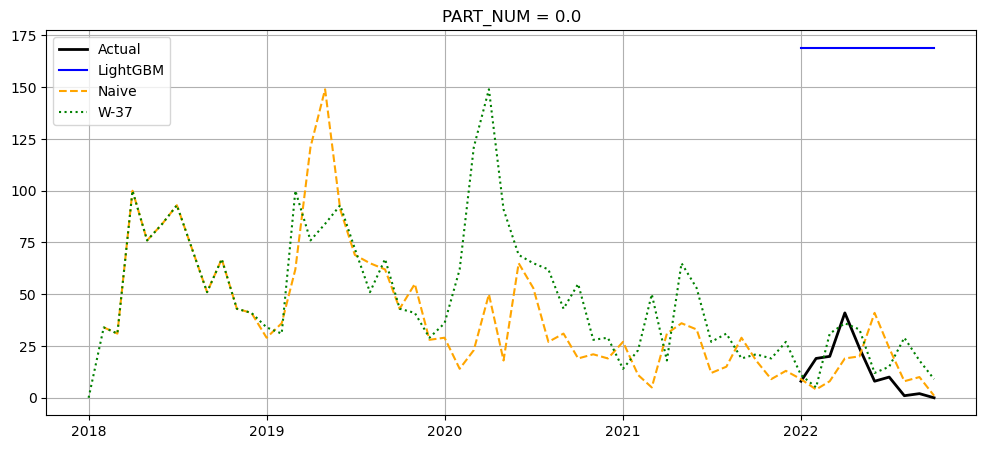

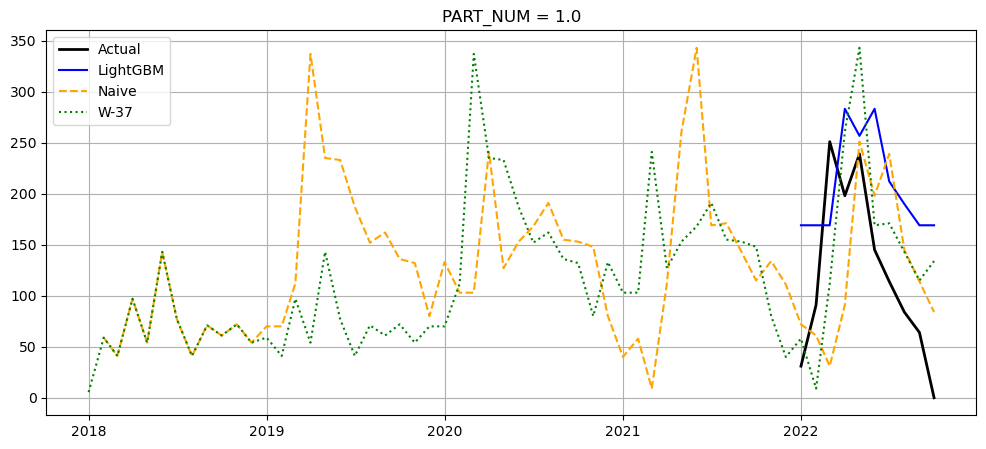

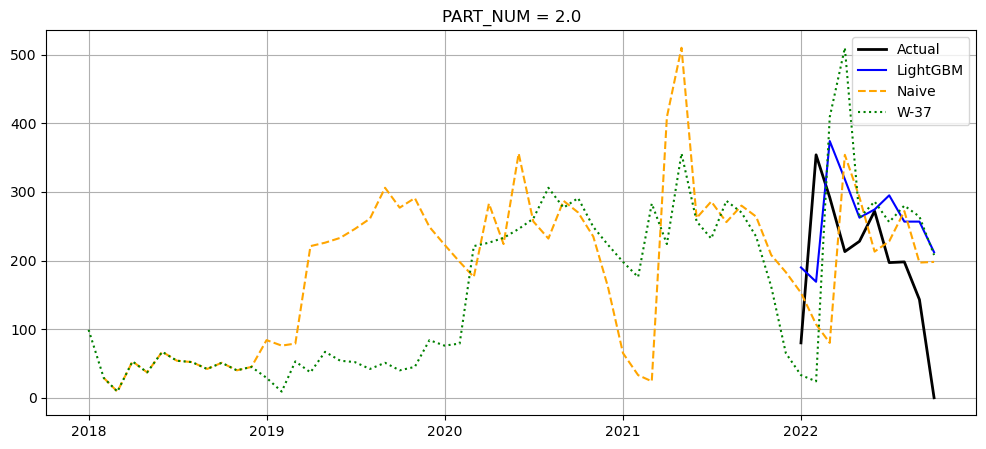

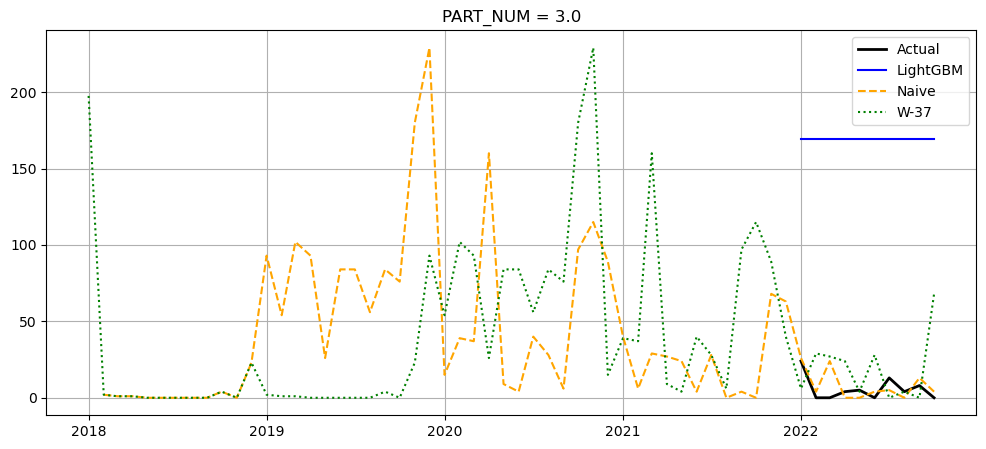

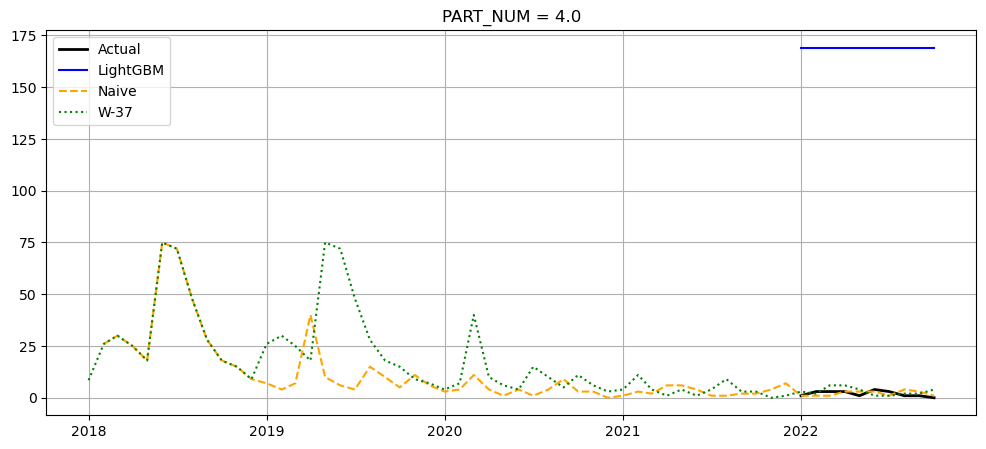

In [29]:
import matplotlib.pyplot as plt

# Example plots
for part in df["PART_NUM"].drop_duplicates().head(5):
    plot_predictions(part, prediction_df, actual_df, naive_df, w37_df)


In [30]:
type(m_lgb)

lightgbm.sklearn.LGBMRegressor

In [31]:
from ibm_watson_machine_learning import APIClient

# SET DEPLOYMENT SPACE

# space_id must already exist (from earlier cell or UI)
client.set.default_space(space_id)
print("Using deployment space:", space_id)

# GET SOFTWARE SPECIFICATION

software_spec_id = client.software_specifications.get_id_by_name(
    "runtime-24.1-py3.11"
)

print("Software spec ID:", software_spec_id)

# REGISTER ML MODEL

model_metadata = {
    client.repository.ModelMetaNames.NAME: "demand_forecasting_lgbm",
    client.repository.ModelMetaNames.TYPE: "scikit-learn_1.3",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_UID: software_spec_id
}

model_details = client.repository.store_model(
    model=m_lgb,          # <-- trained model
    meta_props=model_metadata
)

model_id = model_details["metadata"]["id"]
print("Model registered with ID:", model_id)

# CREATE ONLINE DEPLOYMENT

deployment_metadata = {
    client.deployments.ConfigurationMetaNames.NAME: "demand-forecasting-ml",
    client.deployments.ConfigurationMetaNames.ONLINE: {}
}

deployment_details = client.deployments.create(
    artifact_uid=model_id,
    meta_props=deployment_metadata,
    space_id=space_id
)

deployment_id = deployment_details["metadata"]["id"]
scoring_url = deployment_details["entity"]["status"]["online_url"]["url"]

print("Deployment SUCCESSFUL")
print("Deployment ID:", deployment_id)
print("Scoring URL:", scoring_url)


Using deployment space: a6130dad-06f5-4ad7-9ff1-e5ea8b8e77ac
Software spec ID: 45f12dfe-aa78-5b8d-9f38-0ee223c47309
Model registered with ID: b6e9ed24-b072-4e1a-b073-7d6ca1c4a623


######################################################################################

Synchronous deployment creation for id: 'b6e9ed24-b072-4e1a-b073-7d6ca1c4a623' started

######################################################################################


initializing
Note: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
.........
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='d6c19a09-7e09-4826-959d-952dbcc85805'
-----------------------------------------------------------------------------------------------


Deployment SUCCESSFUL
Deployment ID: d6c19a09-7e09-4826-959d-952dbcc85805
Scoring URL: https://us-south.ml.cloud.ibm.com